# How does cost $P$ and number of endpoints $m_t$ change with different $m_0$?
## Imports

In [23]:
from math import pi, sqrt, e, log
from statistics import NormalDist
from scipy.optimize import minimize, Bounds
import matplotlib.pyplot as plt
import numpy as np
import pickle
import tqdm as tqdm

## Constants

In [24]:
N = 2 ** 20
p = 1-e**-2 # our table coverage

## Functions for optimisation

In [25]:
## define the objective and target functions
def cost(inputs, N, m_0): ## the cost calculation function as objective function to be minimized
    ### the input variables to find are as follows:
    # input[0] is the number of starting points
    # input[1:] is the K_j for all 1<=j<=t
    K_js = inputs[1:] # K_j values
    cost = 0 # cost counter
    m_values = [m_0]    # list to keep the mj values
    
    for k in K_js: # iterate through the column
        # Calculate E1 and E2
        E1 = (1-1/N)**m_0
        E2 = (1-2/N)**m_0
        # calculate the statistical average of m_j+1
        average = N*(1 - E1)
        ## check if the variance is positive, sometimes error happens because of float calculation on very small values
        if N*((N-1)*E2 + E1 - N*E1**2)<0:
            # if it is negative (error), set it to 0
            variance = 0
        else:
            # count the variance otherwise
            variance = sqrt(N*((N-1)*E2 + E1 - N*E1**2))
        # count the cost before defining the new m
        cost += m_0 + m_0 * k/577.44
        # find the m_j+1
        m_0 = average + NormalDist().inv_cdf((k-pi/8)/(k-pi/4+1))*variance
        m_values.append(m_0)
        # count the cost
        
    # return cost - not square rooted as we are bounding cost
    return cost, m_values 

In [26]:
def m_t(inputs, N, m_0):## the m_t function as a target function
    ### the input variables to find are as follows:
    # input[0] is the number of starting points
    # input[1:] is the K_j for all 1<=j<=t
    
    K_js = inputs[1:] # K_j values
    m = m_0 # starting m value
    
    for k in K_js:# iterate through the column
        # Calculate E1 and E2
        E1 = (1-1/N) ** m
        E2 = (1-2/N) ** m
        # calculate the statistical average of m_j+1
        average = N*(1 - E1)
        # check if the variance is positive, sometimes error happens because of float calculation on very small values
        if N*((N-1)*E2 + E1 - N*E1**2)<0:
            # if it is negative (error), set it to 0
            variance = 0
        else:
            # count the statistical variance of m_j+1 otherwise
            variance = sqrt(N*((N-1)*E2 + E1 - N*E1**2))
        # find the m_j+1
        m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * variance
        
    # return -m to maximise the amount of points with optimiser
    return -m

In [27]:
# function to get cost of vanilla rainbow table
def vanilla_cost(N, m_0, t):
    # keep track of cost
    cost = 0
    m = m_0
    m_values = [m]

    # iterate through each column
    for i in range(t):
        # Calculate E1 and E2
        E1 = (1-1/N)**m
        E2 = (1-2/N)**m
        average = N*(1 - E1)
        
        # check variance
        if N*((N-1)*E2 + E1 - N*E1**2)<0:
            # if it is negative (error), set it to 0
            variance = 0
        else:
            # count the variance otherwise
            variance = sqrt(N*((N-1)*E2 + E1 - N*E1**2))
            
        # calculate cost - add 1 for each hash we do (m hashes in this column)
        cost = cost + m
            
        # find the m_j+1
        m = average + NormalDist().inv_cdf((1-pi/8)/(1-pi/4+1))*variance
        m_values.append(m)
        
    return cost, m_values

In [28]:
# Optimise 
# add vcost to bound the optimisation
def optimise_kj(N, p, alpha):   # add v_cost if want vanilla cost to be set beforehand
    t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    mt_target = N**(2/3) # our target mt
    m_0 = round(mt_target/(1-alpha))    # our starting m_0
    
    ## set the bound and target function
    # lower bounds and upper bounds for the input variables
    bound = Bounds([1 for i in range(t)], [float("inf") for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = vanilla_cost(N, m_0, t)
    v_cost = v_cost * 1.125
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - cost(x, N, m_0)[0]}

    # P(vanilla) - P(cherry) > 0 the same precomputation cost
    # but want the vanilla cost to be set beforehand
    # ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    
    ## call the optimizer
    # maximise the 
    res = minimize(lambda Kj: m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": 5000000, "eps":0.5})
    
    ## res.x is the result of the optimization
    print(m_0)
    print(t)
    print(len(res.x))
    final_cost, m_values = cost(res.x, N, m_0) # calculate the final cost and m values
    print(f"Final cost: {final_cost}")
    print(f"Final m_t: {m_values[-1]}")
    return res.x, m_0, final_cost, m_values
    

## Plot

In [29]:
def plot_kjs(K_js, m_0, alpha, N):
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
   
    ax.plot(K_js, "k", label = "K")
    ax.set_ylabel(r"$K_{j}$", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12, "labelpad":-2})
    ax.set_xlabel("j", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12})
    
    fig.suptitle(f"K curve where $m_0$ = {m_0} ($α$ = {alpha}), N = {N}, t = {len(K_js)}")
    plt.savefig(f"plots/cherry_w_vanilla/K_curve_alpha_{alpha}_N_{N}.png")

In [30]:
def plot_mjs(m_values, alpha, N):
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    
    ax.plot(m_values, "k", label = "m")
    ax.set_ylabel(r"$m_{j}$", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12, "labelpad":-2})
    ax.set_xlabel("j", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12})
    
    fig.suptitle(f"Number of unique elements per column where $m_0$ = {m_values[0]} ($α$ = {alpha}), N = {N}, t = {len(m_values)}")
    plt.savefig(f"plots/cherry_w_vanilla/m_curve_alpha_{alpha}_N_{N}.png")

## Approximate $m_t$ and $P$ 

In [31]:
def test_m0():
    # different maximality factors
    alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    results = []
    
    for alpha in alphas:
        K_js, m_0, final_cost, m_values = optimise_kj(N, p, alpha)
        results.append([K_js, m_0, final_cost, m_values])
        
        plot_kjs(K_js, m_0, alpha, "$2^{20}$")
        plot_mjs(m_values, alpha, "$2^{20}$")
        
    return results
    

In [32]:
def test_alpha():
    # different maximality factors
    # alphas = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65]
    alphas = [0.552, 0.554, 0.556, 0.558]
    
    # get the vanilla cost to bound optimisation
    t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    mt_target = N**(2/3) # our target mt
    m_0_v = round(mt_target/(1-0.9))    # our starting m_0
    vcost, m = vanilla_cost(N, m_0_v, t)
    print('Vanilla mt:', m[-1])
    
    results = []
    
    for alpha in alphas:
        K_js, m_0, final_cost, m_values = optimise_kj(N, p, alpha, vcost)
        results.append([K_js, m_0, final_cost, m_values])
        
        plot_kjs(K_js, m_0, alpha, "$2^{20}$")
        
        # plot mjs with vanilla costs
        fig = plt.figure()
        ax = fig.add_subplot(1,1,1)
    
        ax.plot(m_values, label = "Cherry Table")
        ax.plot(m, label = "Vanilla Table")
        
        
        ax.set_ylabel(r"$m_{j}$", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12, "labelpad":-2})
        ax.set_xlabel("j", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12})
        
        fig.suptitle(f"Number of unique elements per column for different $m_0$ = {m[0]} & {m_0} values, N = {N}")
        plt.legend()
        plt.savefig(f"plots/cherry_v_vanilla/m_curve_alpha_{alpha}.png")
        
    return results

Optimization terminated successfully    (Exit mode 0)
            Current function value: -8339.804541302941
            Iterations: 146
            Function evaluations: 29784
            Gradient evaluations: 146
20643
202
202
Final cost: 2588274.2733284174
Final m_t: 8339.804541302941
Optimization terminated successfully    (Exit mode 0)
            Current function value: -8914.040844513402
            Iterations: 133
            Function evaluations: 27143
            Gradient evaluations: 133
25803
202
202
Final cost: 2952765.7916423385
Final m_t: 8914.040844513402
Optimization terminated successfully    (Exit mode 0)
            Current function value: -9574.379046679082
            Iterations: 142
            Function evaluations: 28948
            Gradient evaluations: 142
34404
202
202
Final cost: 3458321.129244786
Final m_t: 9574.379046679082
Optimization terminated successfully    (Exit mode 0)
            Current function value: -9943.512057729198
            Iterations: 1

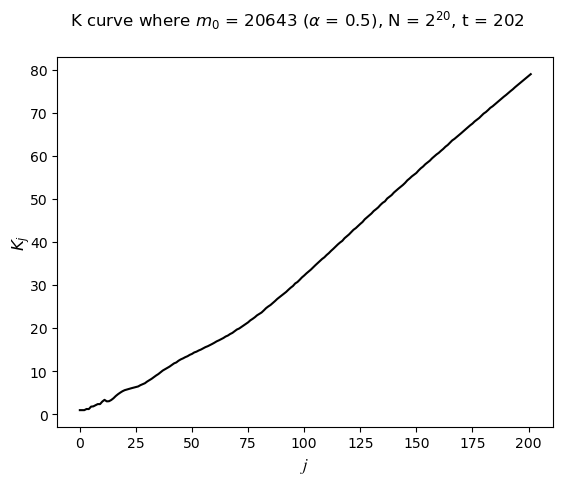

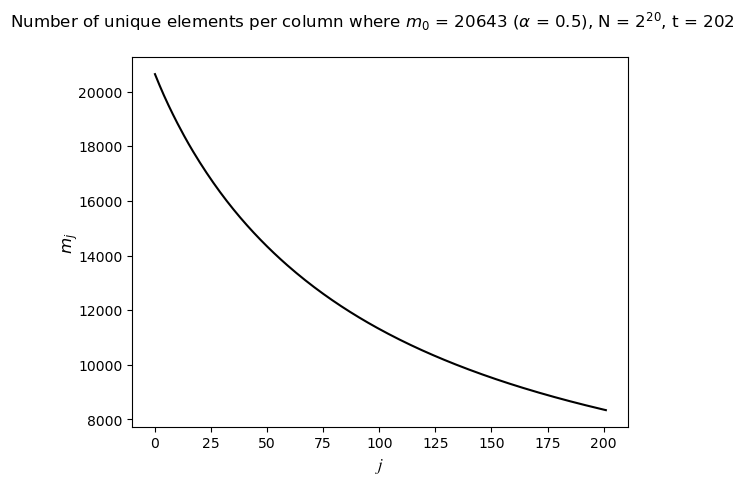

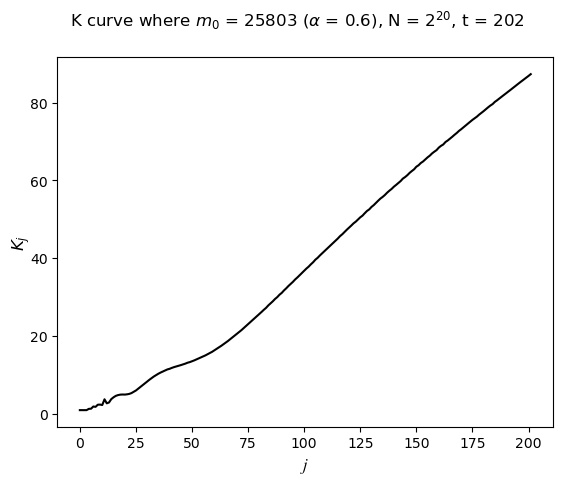

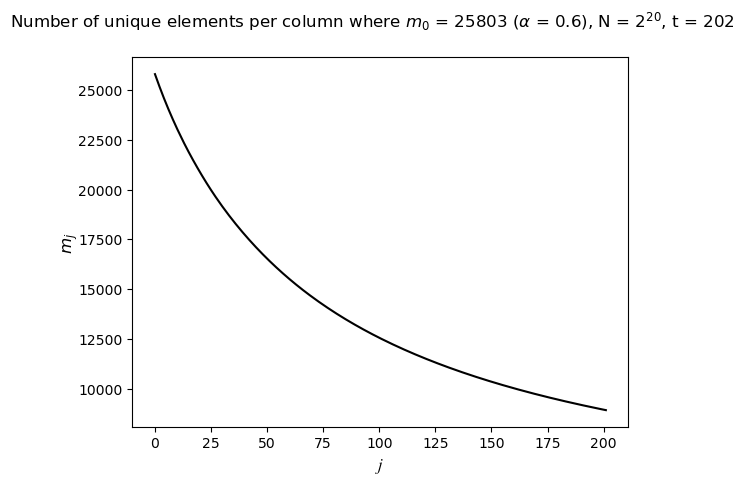

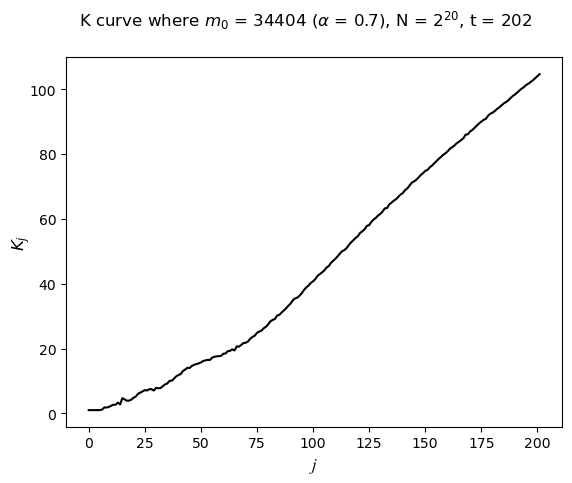

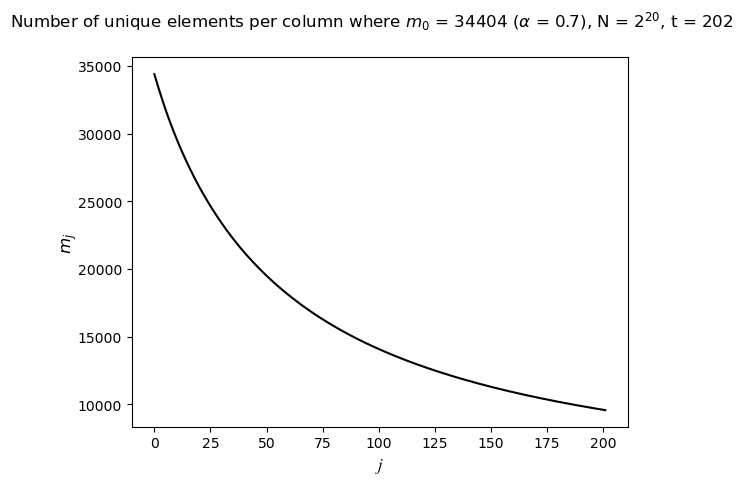

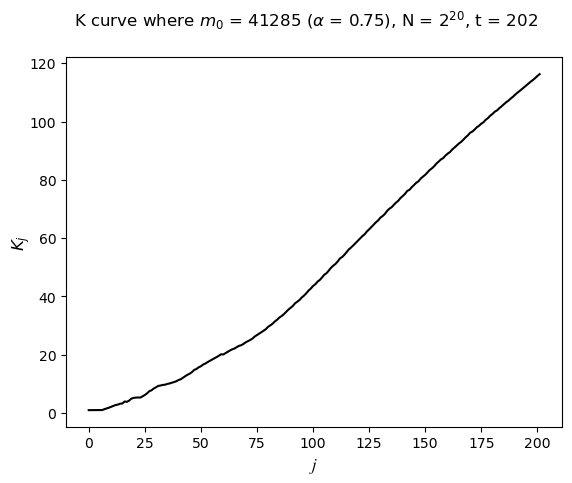

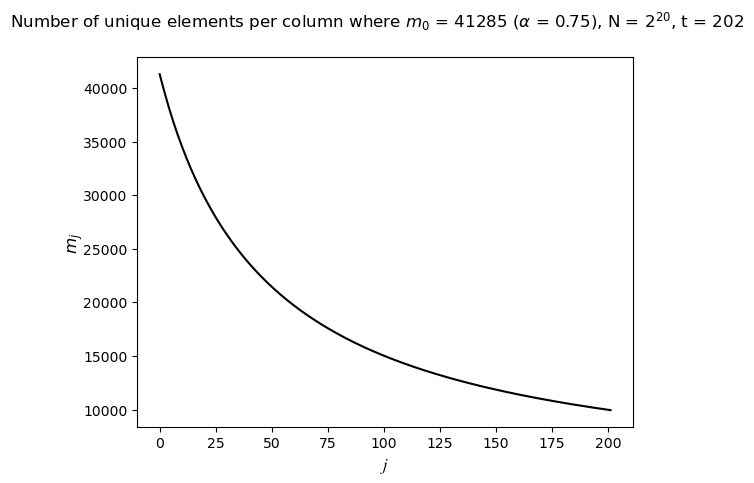

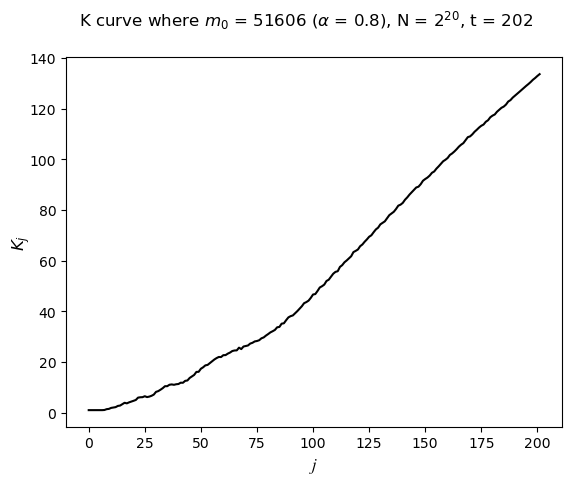

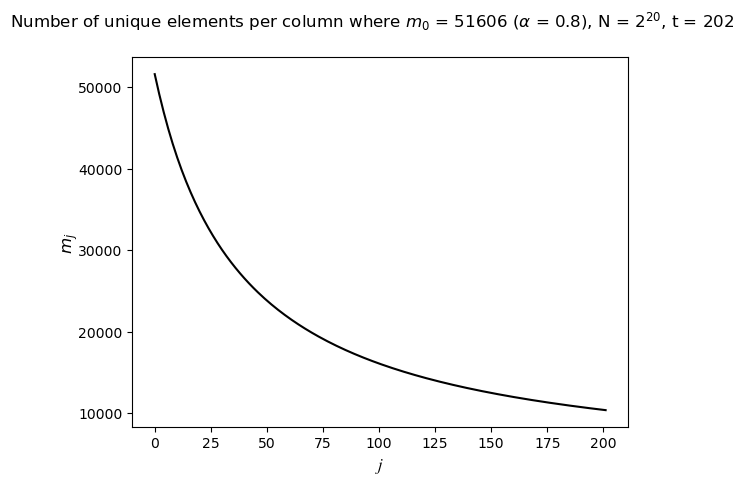

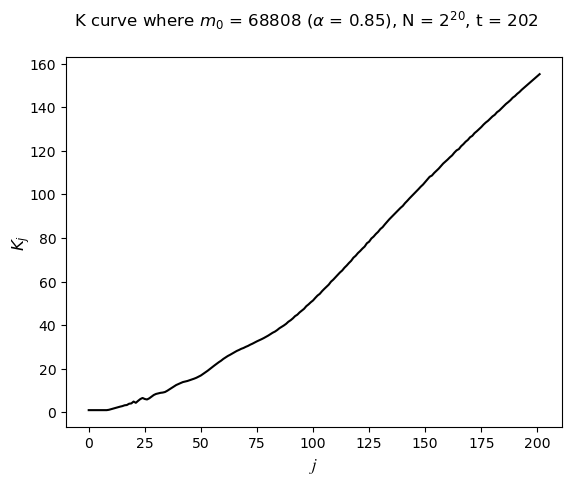

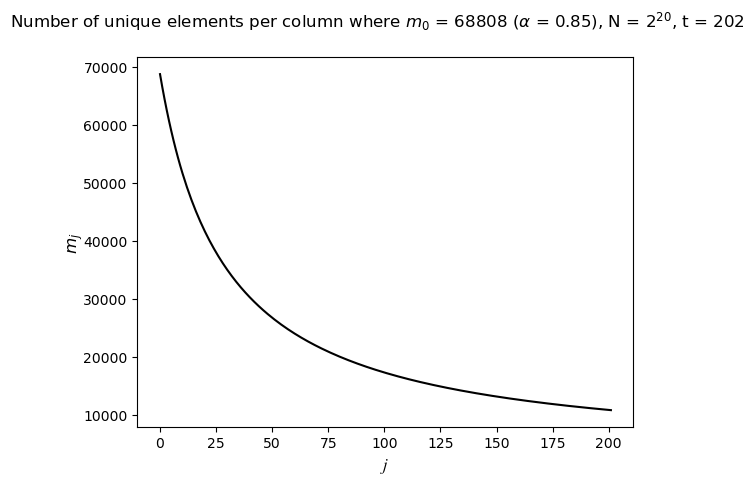

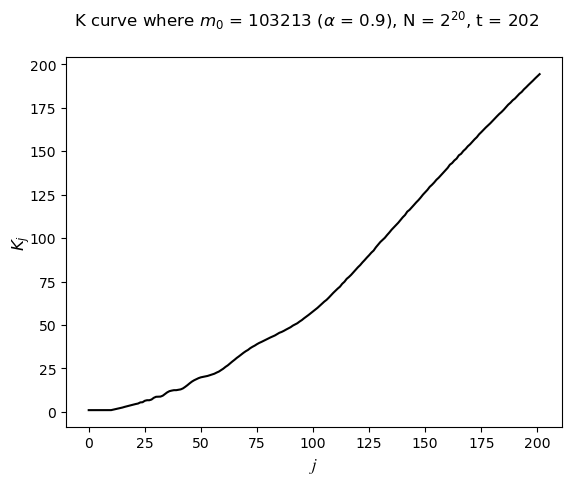

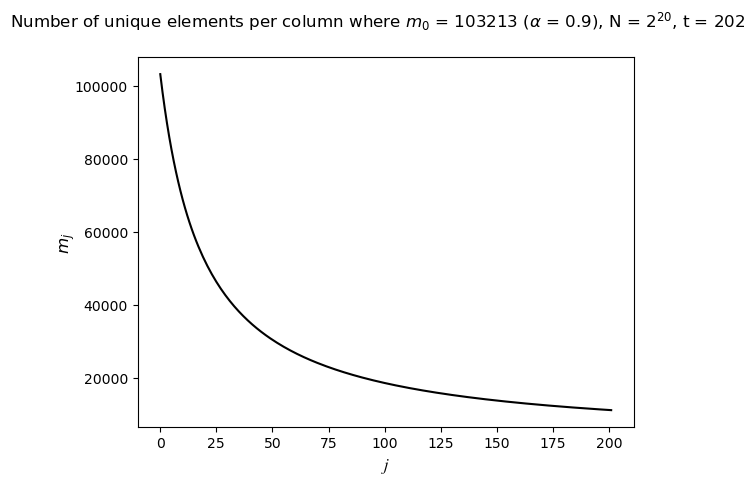

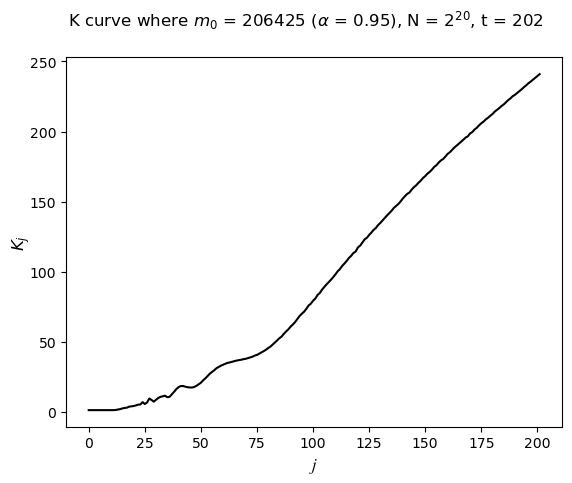

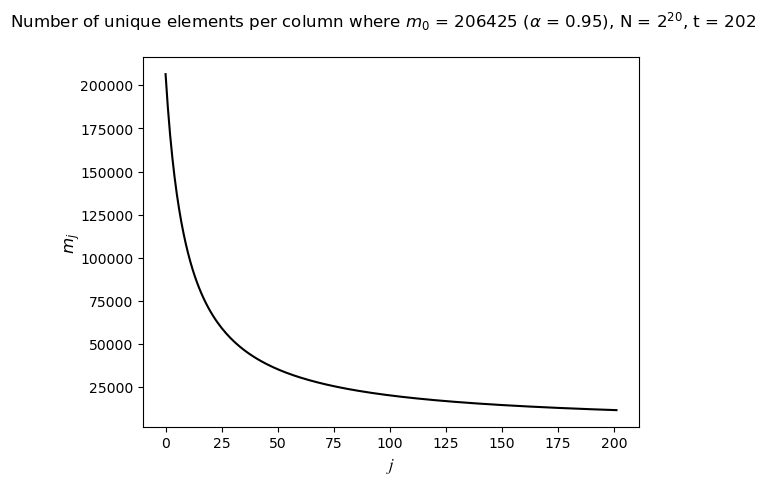

In [33]:
# this will test different maximality factors defined in the function and plot the results
results = test_m0()
# this will test different maximality factors defined in the function and plot the results
# results = test_alpha()

## Plot all on one axis

In [34]:
def plot_all_kj(results, N):
    # [K_js, m_0, final_cost, m_values
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    
    alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    
    for i, result in enumerate(results):
        K_js = result[0]
        alpha = alphas[i]
        ax.plot(K_js, label = f"α = {alpha}")
    
    ax.set_ylabel(r"$K_{j}$", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12, "labelpad":-2})
    ax.set_xlabel("j", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12})
    
    fig.suptitle(f"K curve for different $m_0$ values, N = {N}")
    plt.legend()
    plt.savefig(f"plots/cherry_w_vanilla/K_curve_all_N_{N}.png")

In [35]:
def plot_all_mj(results, N):
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    
    for result in results:
        m_values = result[3]
        ax.plot(m_values, label = f"$m_0$ = {result[1]}")
    
    ax.set_ylabel(r"$m_{j}$", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12, "labelpad":-2})
    ax.set_xlabel("j", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12})
    
    fig.suptitle(f"Number of unique elements per column for different $m_0$ values, N = {N}")
    plt.legend()
    plt.savefig(f"plots/cherry_w_vanilla/m_curve_all_N_{N}.png")

In [36]:
# plot m_0 and cost
def plot_costs(results, N):
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    
    # put data into x array and y array
    x_coords = []
    y_coords = []
    
    for result in results:
        x_coords.append(result[1])
        y_coords.append(result[2])
        
    print(y_coords)
    # line of best fit
    coefficients = np.polyfit(x_coords, y_coords, 1)    
    poly = np.poly1d(coefficients)
    
    # plot data and line of best fit
    ax.scatter(x_coords, y_coords, )
    ax.plot(x_coords, poly(x_coords))
    
    ax.set_ylabel("Final Cost", **{"fontname": "Times New Roman", "fontsize":12, "labelpad":-2})
    ax.set_xlabel("$m_0$", **{"fontname": "Times New Roman", "style":"italic", "fontsize":12})
    
    # attempt to fix the scientific notation
    ax.ticklabel_format( axis='y', style='sci', scilimits=(13,13))
    
    fig.suptitle(f"Final cost for different $m_0$ values, N = {N}")
    plt.savefig(f"plots/cherry_w_vanilla/costs_N_{N}.png")
    

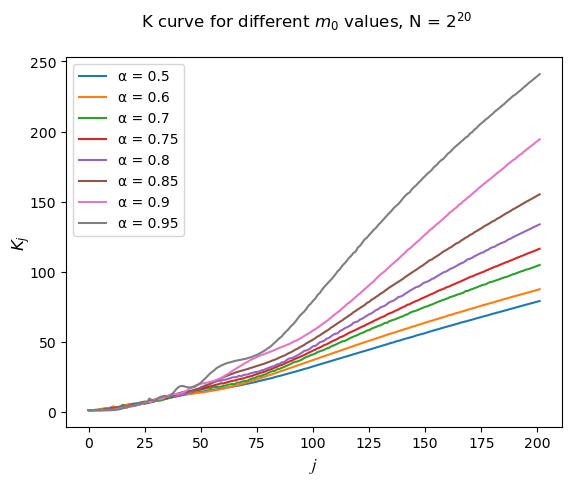

In [37]:
plot_all_kj(results, "$2^{20}$")

In [38]:
## TODO: Fix these results because they got overwritten
with open('1.125_results.pkl', 'wb') as f:
    pickle.dump(results, f)

In [39]:
# store all the vanilla rainbow table costs and points
# all the alpha
alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
results = []

for alpha in alphas:
    t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    mt_target = N**(2/3) # our target mt
    m_0 = round(mt_target/(1-alpha))    # our starting m_0
    v_cost, m_values = vanilla_cost(N, m_0, t)
    results.append([v_cost, m_values])
    
with open('1.125_vanilla.pkl', 'wb') as f:
    pickle.dump(results, f)
    